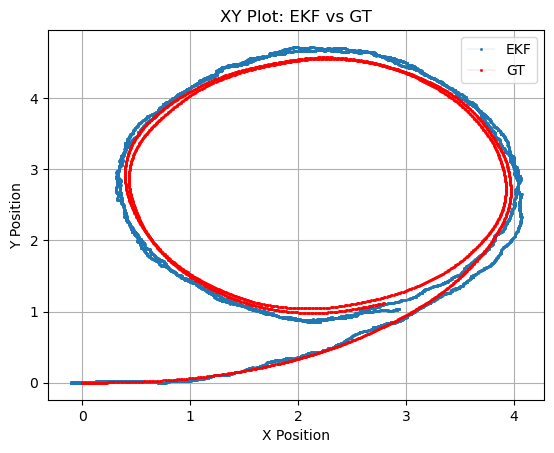

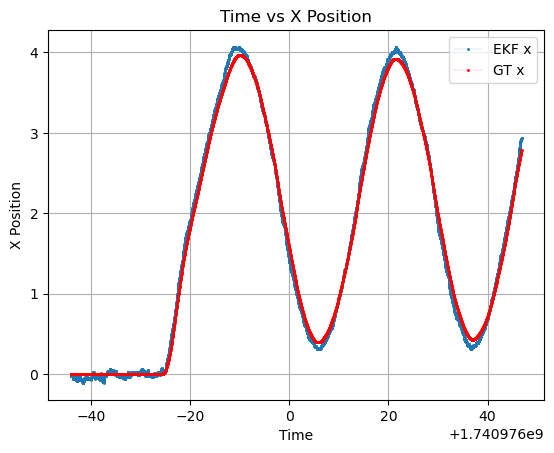

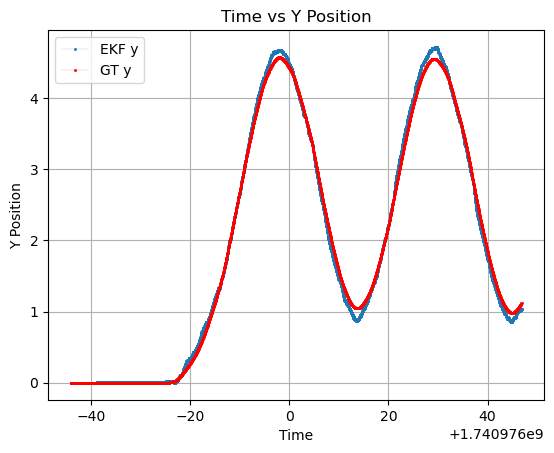

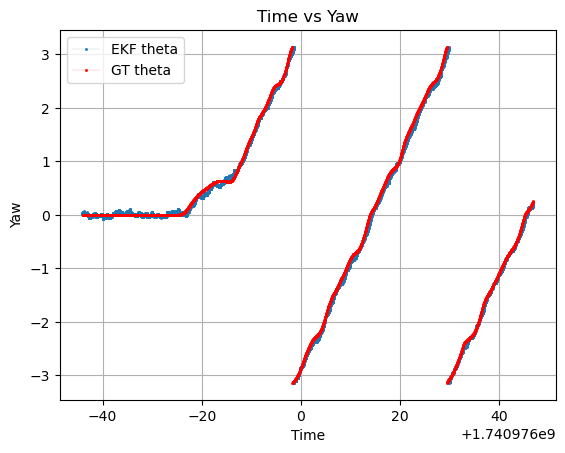

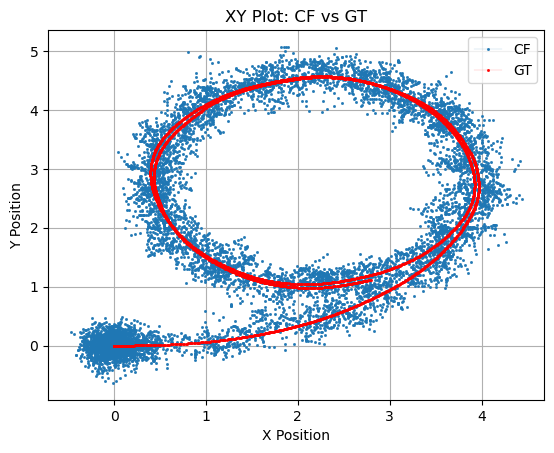

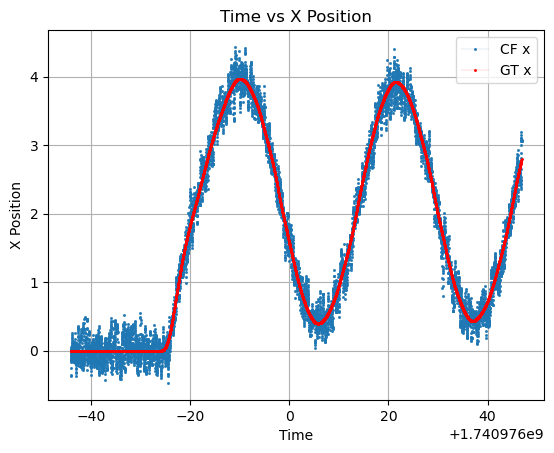

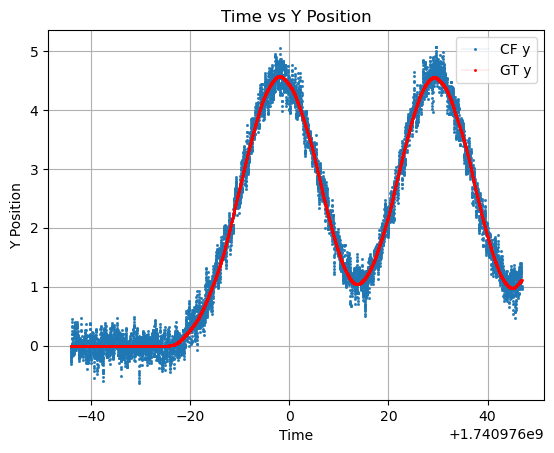

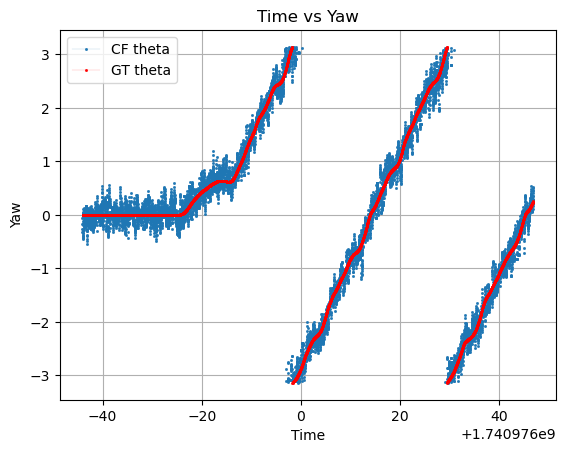

MSE for X Position: nan
MSE for Y Position: nan
MSE for Yaw: nan


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace 'data.csv' with your CSV file path.
csv_file = 'run1.csv'
df = pd.read_csv(csv_file)

# Extract time and topic data
time = df['__time']

# /estimate_odom data: position and yaw
odom_x = df['/estimate_odom/pose/pose/position/x']
odom_y = df['/estimate_odom/pose/pose/position/y']
odom_yaw = df['/estimate_odom/pose/pose/orientation/yaw']

# /sim_ground_truth data: position and yaw
sim_x = df['/sim_ground_truth/pose/pose/position/x']
sim_y = df['/sim_ground_truth/pose/pose/position/y']
sim_yaw = df['/sim_ground_truth/pose/pose/orientation/yaw']


ukf_x = df['/ukf_odom/pose/pose/position/x']
ukf_y = df['/ukf_odom/pose/pose/position/y']
ukf_yaw = df['/ukf_odom/pose/pose/orientation/yaw']



# ----------------------------
# 1. XY Plot (Position: x vs y)
plt.figure()
plt.plot(odom_x, odom_y, label='EKF',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(sim_x, sim_y, label='GT',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('XY Plot: EKF vs GT')
plt.legend()
plt.grid(True)

# ----------------------------
# 2. Time vs X Plot
plt.figure()
plt.plot(time, odom_x, label='EKF x',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_x, label='GT x',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('X Position')
plt.title('Time vs X Position')
plt.legend()
plt.grid(True)

# ----------------------------
# 3. Time vs Y Plot
plt.figure()
plt.plot(time, odom_y, label='EKF y',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_y, label='GT y',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('Y Position')
plt.title('Time vs Y Position')
plt.legend()
plt.grid(True)

# ----------------------------
# 4. Time vs Yaw Plot
plt.figure()
plt.plot(time, odom_yaw, label='EKF theta',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_yaw, label='GT theta',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('Yaw')
plt.title('Time vs Yaw')
plt.legend()
plt.grid(True)


# Plotting
plt.figure()
plt.plot(ukf_x, ukf_y, label='CF',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(sim_x, sim_y, label='GT',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('XY Plot: CF vs GT')
plt.legend()
plt.grid(True)


# 2. Time vs X Plot
plt.figure()
plt.plot(time, ukf_x, label='CF x',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_x, label='GT x',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('X Position')
plt.title('Time vs X Position')
plt.legend()
plt.grid(True)

# ----------------------------
# 3. Time vs Y Plot
plt.figure()
plt.plot(time, ukf_y, label='CF y',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_y, label='GT y',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('Y Position')
plt.title('Time vs Y Position')
plt.legend()
plt.grid(True)

# ----------------------------
# 4. Time vs Yaw Plot
plt.figure()
plt.plot(time, ukf_yaw, label='CF theta',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1)
plt.plot(time, sim_yaw, label='GT theta',
         marker='o', markersize=2, markeredgewidth=0.1,
         linestyle='-', linewidth=0.1, color='red')
plt.xlabel('Time')
plt.ylabel('Yaw')
plt.title('Time vs Yaw')
plt.legend()
plt.grid(True)

# Display all plots
plt.show()


# Calculate Mean Squared Error (MSE) for each series
mse_x = np.mean((odom_x - sim_x)**2)
mse_y = np.mean((odom_y - sim_y)**2)
mse_yaw = np.mean((odom_yaw - sim_yaw)**2)

print("MSE for X Position:", mse_x)
print("MSE for Y Position:", mse_y)
print("MSE for Yaw:", mse_yaw)


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace 'data.csv' with your CSV file path.
csv_file = 'run1.csv'
df = pd.read_csv(csv_file)

# Convert __time to numeric and create a new 'time' column.
df['time'] = pd.to_numeric(df['__time'], errors='coerce')
print("Original time range:", df['time'].min(), df['time'].max())

# ---------------------------------------------------
# Filter rows so that each DataFrame only contains its topic data.
# For /estimate_odom, keep rows where the odom x field is not NaN.
odom_df = df[['time', 
              '/estimate_odom/pose/pose/position/x',
              '/estimate_odom/pose/pose/position/y',
              '/estimate_odom/pose/pose/orientation/yaw']].copy()
odom_df = odom_df.dropna(subset=['/estimate_odom/pose/pose/position/x'])

# For /sim_ground_truth, keep rows where the sim x field is not NaN.
sim_df = df[['time', 
             '/sim_ground_truth/pose/pose/position/x',
             '/sim_ground_truth/pose/pose/position/y',
             '/sim_ground_truth/pose/pose/orientation/yaw']].copy()
sim_df = sim_df.dropna(subset=['/sim_ground_truth/pose/pose/position/x'])

# ---------------------------------------------------
# Convert the relevant columns to numeric.
odom_df['/estimate_odom/pose/pose/position/x'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/position/x'], errors='coerce')
odom_df['/estimate_odom/pose/pose/position/y'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/position/y'], errors='coerce')
odom_df['/estimate_odom/pose/pose/orientation/yaw'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/orientation/yaw'], errors='coerce')

sim_df['/sim_ground_truth/pose/pose/position/x'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/position/x'], errors='coerce')
sim_df['/sim_ground_truth/pose/pose/position/y'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/position/y'], errors='coerce')
sim_df['/sim_ground_truth/pose/pose/orientation/yaw'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/orientation/yaw'], errors='coerce')

# ---------------------------------------------------
# Rename columns for clarity.
odom_df = odom_df.rename(columns={
    '/estimate_odom/pose/pose/position/x': 'odom_x',
    '/estimate_odom/pose/pose/position/y': 'odom_y',
    '/estimate_odom/pose/pose/orientation/yaw': 'odom_yaw'
})
sim_df = sim_df.rename(columns={
    '/sim_ground_truth/pose/pose/position/x': 'sim_x',
    '/sim_ground_truth/pose/pose/position/y': 'sim_y',
    '/sim_ground_truth/pose/pose/orientation/yaw': 'sim_yaw'
})

# ---------------------------------------------------
# Sort both DataFrames by time.
odom_df = odom_df.sort_values('time')
sim_df = sim_df.sort_values('time')

print("Number of odom entries:", len(odom_df))
print("Number of sim entries:", len(sim_df))

# ---------------------------------------------------
# Use merge_asof to align the two DataFrames based on time.
# Increase tolerance if needed (here set to 0.1 seconds).
merged_df = pd.merge_asof(sim_df, odom_df, on='time', direction='nearest', tolerance=0.1)
print("Rows after merge (before dropping NaNs):", len(merged_df))

# Drop rows where any of the key columns are missing.
merged_df = merged_df.dropna(subset=['odom_x', 'odom_y', 'odom_yaw', 'sim_x', 'sim_y', 'sim_yaw'])
print("Rows after dropping NaNs:", len(merged_df))

if merged_df.empty:
    print("No matching rows found. Consider increasing the tolerance value.")
else:
    # ---------------------------------------------------
    # Calculate Mean Squared Error (MSE) for each series.
    mse_x = np.nanmean((merged_df['odom_x'] - merged_df['sim_x']) ** 2)
    mse_y = np.nanmean((merged_df['odom_y'] - merged_df['sim_y']) ** 2)
    mse_yaw = np.nanmean((merged_df['odom_yaw'] - merged_df['sim_yaw']) ** 2)

    print("MSE for X Position:", mse_x)
    print("MSE for Y Position:", mse_y)
    print("MSE for Yaw:", mse_yaw)

    


Original time range: 1740975955.900538 1740976046.88047
Number of odom entries: 9099
Number of sim entries: 2756
Rows after merge (before dropping NaNs): 2756
Rows after dropping NaNs: 2756
MSE for X Position: 0.006771178598492012
MSE for Y Position: 0.006464030906979586
MSE for Yaw: 0.3646745745807342


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace 'run1.csv' with your CSV file path.
csv_file = 'run1.csv'
df = pd.read_csv(csv_file)

# Convert __time to numeric and create a new 'time' column.
df['time'] = pd.to_numeric(df['__time'], errors='coerce')
print("Original time range:", df['time'].min(), df['time'].max())

# ---------------------------------------------------
# Filter rows for each topic.

# /estimate_odom: keep rows where the odom x field is not NaN.
odom_df = df[['time', 
              '/estimate_odom/pose/pose/position/x',
              '/estimate_odom/pose/pose/position/y',
              '/estimate_odom/pose/pose/orientation/yaw']].copy()
odom_df = odom_df.dropna(subset=['/estimate_odom/pose/pose/position/x'])

# /sim_ground_truth: keep rows where the sim x field is not NaN.
sim_df = df[['time', 
             '/sim_ground_truth/pose/pose/position/x',
             '/sim_ground_truth/pose/pose/position/y',
             '/sim_ground_truth/pose/pose/orientation/yaw']].copy()
sim_df = sim_df.dropna(subset=['/sim_ground_truth/pose/pose/position/x'])

# /ukf_odom: keep rows where the ukf x field is not NaN.
ukf_df = df[['time', 
             '/ukf_odom/pose/pose/position/x',
             '/ukf_odom/pose/pose/position/y',
             '/ukf_odom/pose/pose/orientation/yaw']].copy()
ukf_df = ukf_df.dropna(subset=['/ukf_odom/pose/pose/position/x'])

# ---------------------------------------------------
# Convert the relevant columns to numeric.

# For /estimate_odom.
odom_df['/estimate_odom/pose/pose/position/x'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/position/x'], errors='coerce')
odom_df['/estimate_odom/pose/pose/position/y'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/position/y'], errors='coerce')
odom_df['/estimate_odom/pose/pose/orientation/yaw'] = pd.to_numeric(
    odom_df['/estimate_odom/pose/pose/orientation/yaw'], errors='coerce')

# For /sim_ground_truth.
sim_df['/sim_ground_truth/pose/pose/position/x'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/position/x'], errors='coerce')
sim_df['/sim_ground_truth/pose/pose/position/y'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/position/y'], errors='coerce')
sim_df['/sim_ground_truth/pose/pose/orientation/yaw'] = pd.to_numeric(
    sim_df['/sim_ground_truth/pose/pose/orientation/yaw'], errors='coerce')

# For /ukf_odom.
ukf_df['/ukf_odom/pose/pose/position/x'] = pd.to_numeric(
    ukf_df['/ukf_odom/pose/pose/position/x'], errors='coerce')
ukf_df['/ukf_odom/pose/pose/position/y'] = pd.to_numeric(
    ukf_df['/ukf_odom/pose/pose/position/y'], errors='coerce')
ukf_df['/ukf_odom/pose/pose/orientation/yaw'] = pd.to_numeric(
    ukf_df['/ukf_odom/pose/pose/orientation/yaw'], errors='coerce')

# ---------------------------------------------------
# Rename columns for clarity.
odom_df = odom_df.rename(columns={
    '/estimate_odom/pose/pose/position/x': 'odom_x',
    '/estimate_odom/pose/pose/position/y': 'odom_y',
    '/estimate_odom/pose/pose/orientation/yaw': 'odom_yaw'
})
sim_df = sim_df.rename(columns={
    '/sim_ground_truth/pose/pose/position/x': 'sim_x',
    '/sim_ground_truth/pose/pose/position/y': 'sim_y',
    '/sim_ground_truth/pose/pose/orientation/yaw': 'sim_yaw'
})
ukf_df = ukf_df.rename(columns={
    '/ukf_odom/pose/pose/position/x': 'ukf_x',
    '/ukf_odom/pose/pose/position/y': 'ukf_y',
    '/ukf_odom/pose/pose/orientation/yaw': 'ukf_yaw'
})

# ---------------------------------------------------
# Sort all DataFrames by time.
odom_df = odom_df.sort_values('time')
sim_df = sim_df.sort_values('time')
ukf_df = ukf_df.sort_values('time')

print("Number of odom entries:", len(odom_df))
print("Number of sim entries:", len(sim_df))
print("Number of ukf entries:", len(ukf_df))

# ---------------------------------------------------
# Merge /estimate_odom and /sim_ground_truth based on time.
merged_odom_sim = pd.merge_asof(sim_df, odom_df, on='time', direction='nearest', tolerance=0.1)
merged_odom_sim = merged_odom_sim.dropna(subset=['odom_x', 'odom_y', 'odom_yaw', 'sim_x', 'sim_y', 'sim_yaw'])
print("Rows after merging odom with sim:", len(merged_odom_sim))

# Merge /ukf_odom and /sim_ground_truth based on time.
merged_ukf_sim = pd.merge_asof(sim_df, ukf_df, on='time', direction='nearest', tolerance=0.1)
merged_ukf_sim = merged_ukf_sim.dropna(subset=['ukf_x', 'ukf_y', 'ukf_yaw', 'sim_x', 'sim_y', 'sim_yaw'])
print("Rows after merging ukf with sim:", len(merged_ukf_sim))

# ---------------------------------------------------
# Compute MSE for /estimate_odom versus ground truth.
if merged_odom_sim.empty:
    print("No matching rows found for /estimate_odom and sim_ground_truth. Consider increasing the tolerance value.")
else:
    mse_odom_x = np.nanmean((merged_odom_sim['odom_x'] - merged_odom_sim['sim_x']) ** 2)
    mse_odom_y = np.nanmean((merged_odom_sim['odom_y'] - merged_odom_sim['sim_y']) ** 2)
    mse_odom_yaw = np.nanmean((merged_odom_sim['odom_yaw'] - merged_odom_sim['sim_yaw']) ** 2)
    print("MSE for /estimate_odom X Position:", mse_odom_x)
    print("MSE for /estimate_odom Y Position:", mse_odom_y)
    print("MSE for /estimate_odom Yaw:", mse_odom_yaw)

# Compute MSE for /ukf_odom versus ground truth.
if merged_ukf_sim.empty:
    print("No matching rows found for /ukf_odom and sim_ground_truth. Consider increasing the tolerance value.")
else:
    mse_ukf_x = np.nanmean((merged_ukf_sim['ukf_x'] - merged_ukf_sim['sim_x']) ** 2)
    mse_ukf_y = np.nanmean((merged_ukf_sim['ukf_y'] - merged_ukf_sim['sim_y']) ** 2)
    mse_ukf_yaw = np.nanmean((merged_ukf_sim['ukf_yaw'] - merged_ukf_sim['sim_yaw']) ** 2)
    print("MSE for /ukf_odom X Position:", mse_ukf_x)
    print("MSE for /ukf_odom Y Position:", mse_ukf_y)
    print("MSE for /ukf_odom Yaw:", mse_ukf_yaw)


Original time range: 1740975955.900538 1740976046.88047
Number of odom entries: 9099
Number of sim entries: 2756
Number of ukf entries: 9098
Rows after merging odom with sim: 2756
Rows after merging ukf with sim: 2756
MSE for /estimate_odom X Position: 0.006771178598492012
MSE for /estimate_odom Y Position: 0.006464030906979586
MSE for /estimate_odom Yaw: 0.3646745745807342
MSE for /ukf_odom X Position: 0.032429996244513565
MSE for /ukf_odom Y Position: 0.03269955863507731
MSE for /ukf_odom Yaw: 0.43640895920604583
